# CIFAR-10 Image Classification with Transfer Learning Using ResNet50

This notebook presents an end-to-end computer vision workflow for classifying small RGB images from the **CIFAR-10** dataset. The project uses **transfer learning** with **ResNet50** as a pre-trained convolutional base and a custom classification head adapted to the ten CIFAR-10 classes.

The main goal is not only to obtain a working model, but also to demonstrate clear reasoning about the data, preprocessing, model design, training strategy, evaluation, and limitations.

| Project component | Description |
|---|---|
| Dataset | CIFAR-10 image classification dataset |
| Task | Multi-class image classification |
| Input shape | 32 × 32 × 3 RGB images |
| Number of classes | 10 |
| Main model | ResNet50 with ImageNet pre-trained weights |
| Strategy | Transfer learning followed by fine-tuning |
| Main evaluation metric | Accuracy on the test set |

> **Notice.** This notebook is structured as a complete project artifact. Markdown cells explain the reasoning, while code cells implement the workflow step by step.

## 1. Problem Statement

The objective of this project is to build a neural network that can classify an image into one of ten predefined categories from the CIFAR-10 dataset. CIFAR-10 contains 50,000 training images and 10,000 test images, where each image has a resolution of 32 × 32 pixels and three color channels. The dataset is commonly used as a benchmark for image classification tasks because it is small enough for experimentation but still challenging due to the low image resolution and visual similarity between some classes.[1]

Unlike grayscale datasets such as Fashion MNIST, CIFAR-10 contains **RGB images**, which means that the model must learn from color and texture information in addition to shape. This makes the task more realistic from a computer vision perspective.

| Challenge | Why it matters |
|---|---|
| Low resolution | Objects may be difficult to identify because each image is only 32 × 32 pixels. |
| Ten visual categories | The model must learn discriminative features for several object types. |
| Similar-looking classes | Some classes, such as cats and dogs or automobiles and trucks, may be confused. |
| Limited project sample | The training set is intentionally limited to 10,000 images to reduce runtime. |

> **Notice.** The project instructions require using only 10,000 training images. This limitation makes the workflow faster, but it can also reduce final model performance.

## 2. Environment Setup

The project is designed to run in **Google Colab**. If Colab is slow, the runtime should be changed to a GPU runtime. A GPU is strongly recommended because convolutional neural networks and fine-tuning can take a long time on CPU.

The first code cell imports the libraries needed for data handling, visualization, model building, training, and evaluation.

In [1]:
# Core libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Evaluation utilities
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: True


## 3. Loading the CIFAR-10 Dataset

The CIFAR-10 dataset is available directly through `tensorflow.keras.datasets.cifar10`, so there is no need to manually upload image files. The dataset is loaded as NumPy arrays containing training images, training labels, test images, and test labels.[2]

The class names are defined manually because CIFAR-10 labels are stored as integer indices from 0 to 9.

In [2]:
# Load CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# CIFAR-10 class names in label order
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Original training images shape:", train_images.shape)
print("Original training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)
print("Number of classes:", len(class_names))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Original training images shape: (50000, 32, 32, 3)
Original training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Number of classes: 10


## 4. Sampling the Training Data

According to the project instructions, the training set should be limited to **10,000 samples**. This is done once at the beginning of the notebook. The test set is not reduced because it already contains 10,000 images by default.

This sampling decision creates a practical trade-off. Training becomes faster, but the model sees fewer examples and may therefore achieve lower accuracy than a model trained on the full 50,000-image training set.

In [3]:
# Limit the number of training samples according to project instructions
N_TRAIN = 10000

train_images = train_images[:N_TRAIN]
train_labels = train_labels[:N_TRAIN]

print("Limited training images shape:", train_images.shape)
print("Limited training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Limited training images shape: (10000, 32, 32, 3)
Limited training labels shape: (10000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


## 5. Exploratory Data Analysis

Before training a model, it is important to inspect the data visually. This helps confirm that the images and labels were loaded correctly and provides intuition about why the task is challenging.

The next cell displays sample images from the dataset with their corresponding class names.

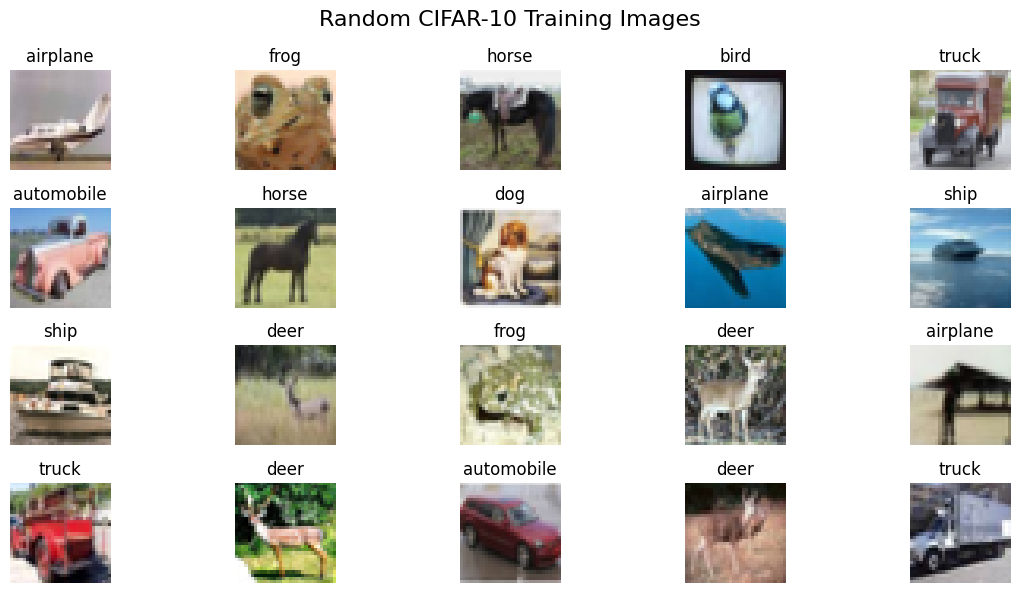

In [4]:
# Display random examples from the training set
plt.figure(figsize=(12, 6))
for i in range(20):
    idx = random.randint(0, len(train_images) - 1)
    plt.subplot(4, 5, i + 1)
    plt.imshow(train_images[idx])
    label_index = int(train_labels[idx][0])
    plt.title(class_names[label_index])
    plt.axis("off")
plt.suptitle("Random CIFAR-10 Training Images", fontsize=16)
plt.tight_layout()
plt.show()

### Class Distribution

A balanced class distribution is important because severe imbalance can make a classifier biased toward more frequent classes. CIFAR-10 is designed to contain the same number of images per class in the full dataset, but after taking the first 10,000 samples, it is still useful to check the distribution in the reduced training subset.

   class_id  class_name  count
0         0    airplane   1005
1         1  automobile    974
2         2        bird   1032
3         3         cat   1016
4         4        deer    999
5         5         dog    937
6         6        frog   1030
7         7       horse   1001
8         8        ship   1025
9         9       truck    981


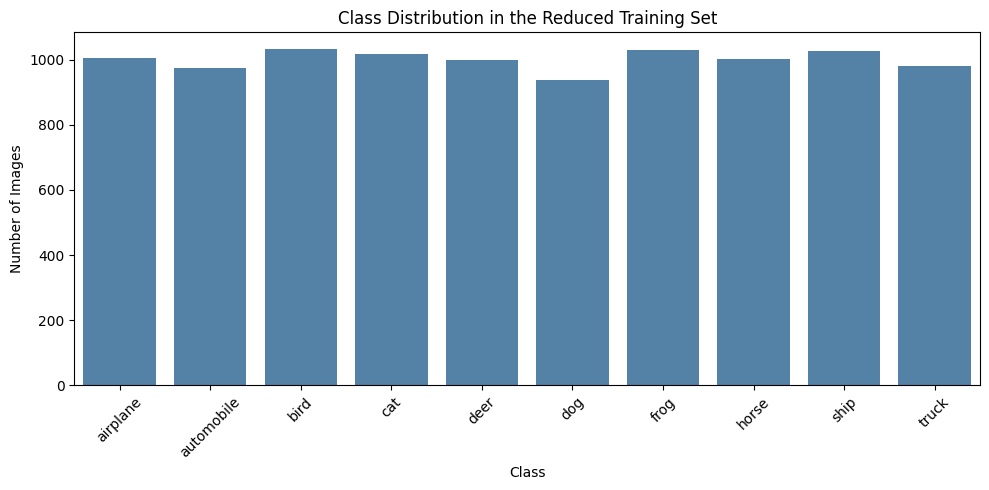

In [5]:
# Analyze class distribution in the reduced training set
train_label_flat = train_labels.flatten()
class_counts = pd.Series(train_label_flat).value_counts().sort_index()
class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

print(class_distribution)

plt.figure(figsize=(10, 5))
sns.barplot(data=class_distribution, x="class_name", y="count", color="steelblue")
plt.xticks(rotation=45)
plt.title("Class Distribution in the Reduced Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## 6. Preprocessing for ResNet50

ResNet50 expects input images to be preprocessed in a specific way. In Keras, this is done using `tf.keras.applications.resnet50.preprocess_input`, which prepares image values in the format expected by the pre-trained ResNet model.[3]

The original CIFAR-10 images are stored as unsigned 8-bit integers with pixel values from 0 to 255. Before applying the ResNet preprocessing function, the images are converted to `float32`.

> **Notice.** We do not resize the images because the project explicitly sets the input shape to **(32, 32, 3)**. ResNet50 can be initialized with this input shape when `include_top=False`.

In [6]:
# Convert images to float32 and apply ResNet50 preprocessing
x_train = preprocess_input(train_images.astype("float32"))
x_test = preprocess_input(test_images.astype("float32"))

# Labels remain integer-encoded because we use sparse categorical crossentropy
y_train = train_labels.astype("int32")
y_test = test_labels.astype("int32")

print("Preprocessed training shape:", x_train.shape)
print("Preprocessed test shape:", x_test.shape)
print("Training data type:", x_train.dtype)
print("Label example:", y_train[0])

Preprocessed training shape: (10000, 32, 32, 3)
Preprocessed test shape: (10000, 32, 32, 3)
Training data type: float32
Label example: [6]


## 7. Transfer Learning Strategy

Transfer learning uses knowledge learned from one large dataset and applies it to a related task. In this project, the convolutional base of ResNet50 is initialized with **ImageNet** weights. These weights contain useful low-level and mid-level visual features such as edges, textures, corners, and object parts.[4]

The model is trained in two phases:

| Phase | Trainable layers | Purpose |
|---|---|---|
| Phase 1: Feature extraction | Only the custom classification head | Learn a CIFAR-10 classifier on top of frozen ResNet50 features. |
| Phase 2: Fine-tuning | ResNet50 base plus classification head | Adapt the pre-trained features more closely to CIFAR-10. |

This two-step approach is safer than immediately training the entire model because the custom head first learns a reasonable mapping from extracted features to CIFAR-10 classes.

## 8. Building the Base Model

The base model is **ResNet50** with `weights="imagenet"` and `include_top=False`. The original ResNet50 classification head is removed because it was designed for ImageNet classes, not CIFAR-10. A new task-specific classification head will be added afterward.

During the first training phase, the base model is frozen by setting `base_model.trainable = False`.

In [7]:
# Build the ResNet50 convolutional base
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)

# Freeze the base model for the first training phase
base_model.trainable = False

print("Number of layers in ResNet50 base:", len(base_model.layers))
print("Base model trainable:", base_model.trainable)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of layers in ResNet50 base: 175
Base model trainable: False


## 9. Adding a Custom Classification Head

Because CIFAR-10 has ten classes, the final layer must output ten probabilities. The custom head uses global average pooling to reduce spatial feature maps, followed by dense layers, dropout, and a softmax output layer.

Dropout is included as a regularization technique. It randomly deactivates some neurons during training, which can reduce overfitting when the training set is relatively small.

In [8]:
# Build complete model: ResNet50 base + custom classification head
inputs = keras.Input(shape=(32, 32, 3), name="input_image")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.BatchNormalization(name="batch_normalization_head")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.35, name="dropout_035")(x)
x = layers.Dense(128, activation="relu", name="dense_128")(x)
x = layers.Dropout(0.25, name="dropout_025")(x)
outputs = layers.Dense(10, activation="softmax", name="cifar10_predictions")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="CIFAR10_ResNet50_TransferLearning")

model.summary()

Model: "CIFAR10_ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_head        │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_035 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_025 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_predictions (Dense)     │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,154,634 (92.14 MB)

 Trainable params: 562,826 (2.15 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## 10. Compiling the Model for Phase 1

The model is compiled with the Adam optimizer, sparse categorical crossentropy loss, and accuracy as the main metric. Sparse categorical crossentropy is appropriate because the labels are integer-encoded rather than one-hot encoded.

A moderate learning rate is used in the first phase because only the newly added head is trainable.

In [11]:
# Compile model for feature extraction phase
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 11. Training Phase 1: Frozen ResNet50 Base

In this phase, the ResNet50 base is frozen and only the custom classification head is trained. This allows the new layers to learn how to map the features extracted by ResNet50 to CIFAR-10 classes.

> **Notice.** The project requirement suggests 10 epochs. If runtime is too slow during experimentation, it is possible to test the notebook with fewer epochs first and then return to 10 epochs for the final version.

In [12]:
# Training parameters
BATCH_SIZE = 64
EPOCHS_HEAD = 10

# Train only the custom classification head
history_head = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS_HEAD,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.4566 - loss: 1.6388 - val_accuracy: 0.5860 - val_loss: 1.2084
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5989 - loss: 1.1542 - val_accuracy: 0.6015 - val_loss: 1.1327
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6654 - loss: 0.9439 - val_accuracy: 0.6190 - val_loss: 1.1112
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7163 - loss: 0.7968 - val_accuracy: 0.6225 - val_loss: 1.1373
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7671 - loss: 0.6487 - val_accuracy: 0.6240 - val_loss: 1.1875
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8027 - loss: 0.5579 - val_accuracy: 0.6325 - val_loss: 1.2391
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8304 - loss: 0.4803 - val_accuracy: 0.6195 - val_loss: 1.3326
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8583 - loss: 0.3924 - val_acc

## 12. Visualizing Training History for Phase 1

Training curves help us understand whether the model is learning and whether overfitting may be occurring. A healthy training process usually shows decreasing loss and increasing accuracy. If training accuracy improves while validation accuracy stagnates or decreases, this can be a sign of overfitting.

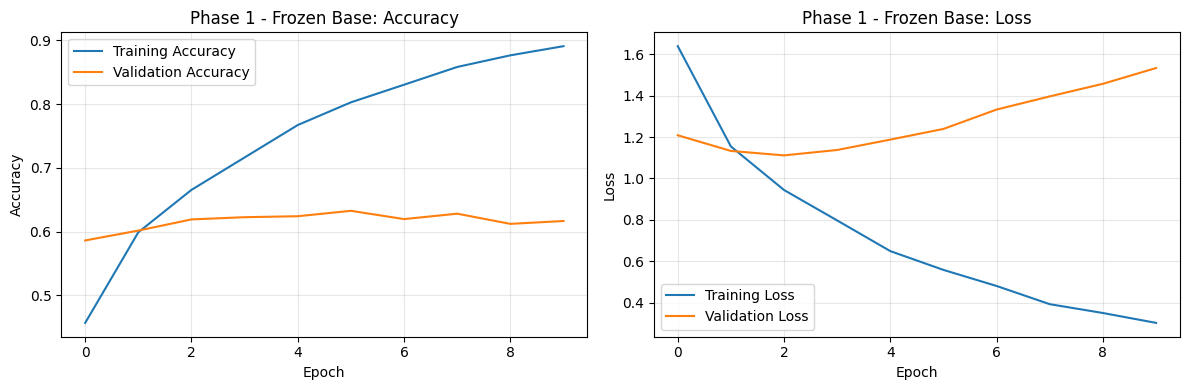

In [13]:
def plot_training_history(history, title_prefix):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["accuracy"], label="Training Accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history_df["loss"], label="Training Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history_head, "Phase 1 - Frozen Base")

## 13. Fine-Tuning Strategy

After the custom head has been trained, the base model is unfrozen so that ResNet50 can adapt its learned features to CIFAR-10. Fine-tuning should be done carefully with a lower learning rate, because large updates can destroy useful pre-trained representations.

In this notebook, the base model is set to trainable, but batch normalization layers are kept frozen. This is a common fine-tuning practice because batch normalization statistics can become unstable when training with small datasets or small batch sizes.

> **Notice.** This phase can be significantly slower than the first phase because many more parameters become trainable.

In [14]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Keep BatchNormalization layers frozen for more stable fine-tuning
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Base model trainable:", base_model.trainable)
print("Total trainable variables:", len(model.trainable_variables))

# Recompile with a lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Base model trainable: True
Total trainable variables: 114


## 14. Training Phase 2: Fine-Tuning the Model

The model is trained again for 10 epochs. Because the convolutional base is now trainable, the model can adjust pre-trained features to better fit CIFAR-10.

The lower learning rate is important because fine-tuning requires small, careful parameter updates.

In [15]:
EPOCHS_FINE = 10

history_fine = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS_FINE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.9087 - loss: 0.2670 - val_accuracy: 0.6350 - val_loss: 1.4645
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9377 - loss: 0.1877 - val_accuracy: 0.6310 - val_loss: 1.4614
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9516 - loss: 0.1578 - val_accuracy: 0.6385 - val_loss: 1.4214
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9611 - loss: 0.1270 - val_accuracy: 0.6465 - val_loss: 1.4170
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9681 - loss: 0.1114 - val_accuracy: 0.6510 - val_loss: 1.4503
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9705 - loss: 0.1039 - val_accuracy: 0.6525 - val_loss: 1.4422
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9783 - loss: 0.0789 - val_accuracy: 0.6540 - val_loss: 1.4663
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9822 - loss: 0.0658 - val_acc

## 15. Visualizing Fine-Tuning History

The fine-tuning curves should be interpreted together with the first training phase. If validation accuracy improves after unfreezing the base model, fine-tuning helped. If validation accuracy becomes unstable or decreases, the learning rate may be too high, the model may be overfitting, or more regularization may be needed.

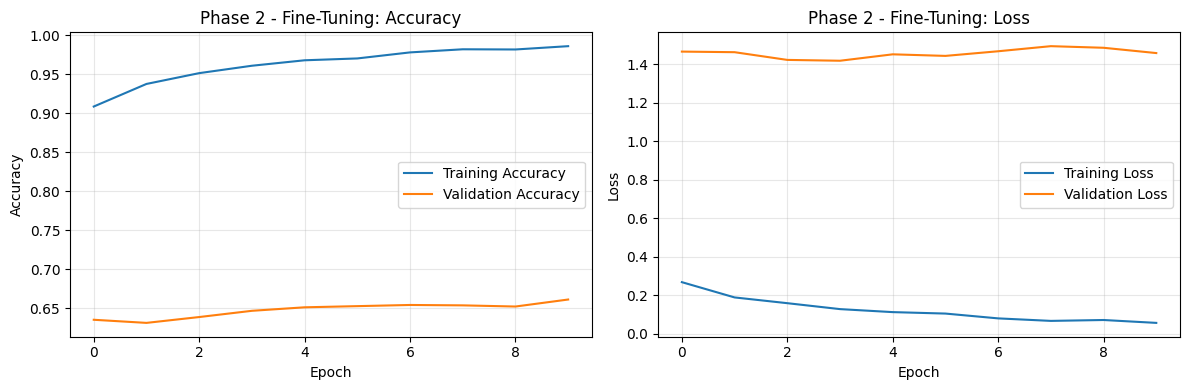

In [16]:
plot_training_history(history_fine, "Phase 2 - Fine-Tuning")

## 16. Final Evaluation on the Test Set

The test set is used only after training to estimate how well the model generalizes to unseen images. This is important because validation metrics during training are used for monitoring, while the test set provides the final evaluation.

In [17]:
# Evaluate the final model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, batch_size=BATCH_SIZE, verbose=1)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6442 - loss: 1.5049
Test loss: 1.5049
Test accuracy: 0.6442


## 17. Confusion Matrix and Classification Report

Accuracy provides a single overall score, but it does not show which classes are difficult for the model. A confusion matrix helps identify class-level mistakes. For example, a model may confuse visually similar categories such as cats and dogs or automobiles and trucks.

157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step


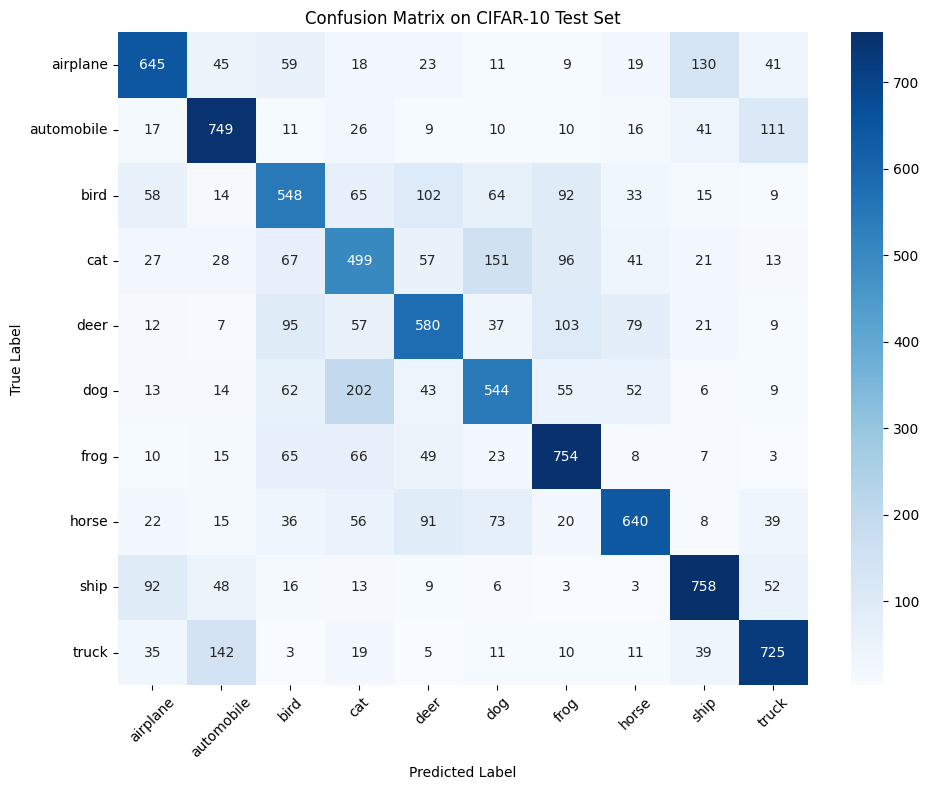

              precision    recall  f1-score   support

    airplane       0.69      0.65      0.67      1000
  automobile       0.70      0.75      0.72      1000
        bird       0.57      0.55      0.56      1000
         cat       0.49      0.50      0.49      1000
        deer       0.60      0.58      0.59      1000
         dog       0.58      0.54      0.56      1000
        frog       0.65      0.75      0.70      1000
       horse       0.71      0.64      0.67      1000
        ship       0.72      0.76      0.74      1000
       truck       0.72      0.72      0.72      1000

    accuracy                           0.64     10000
   macro avg       0.64      0.64      0.64     10000
weighted avg       0.64      0.64      0.64     10000



In [18]:
# Generate predictions for the test set
pred_probabilities = model.predict(x_test, batch_size=BATCH_SIZE, verbose=1)
pred_labels = np.argmax(pred_probabilities, axis=1)
true_labels = y_test.flatten()

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix on CIFAR-10 Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
report = classification_report(true_labels, pred_labels, target_names=class_names)
print(report)

## 18. Inspecting Correct and Incorrect Predictions

Looking at individual predictions is useful because it connects quantitative metrics with visual examples. This can reveal whether mistakes are understandable, such as confusing visually similar classes or images where the object is small or unclear.

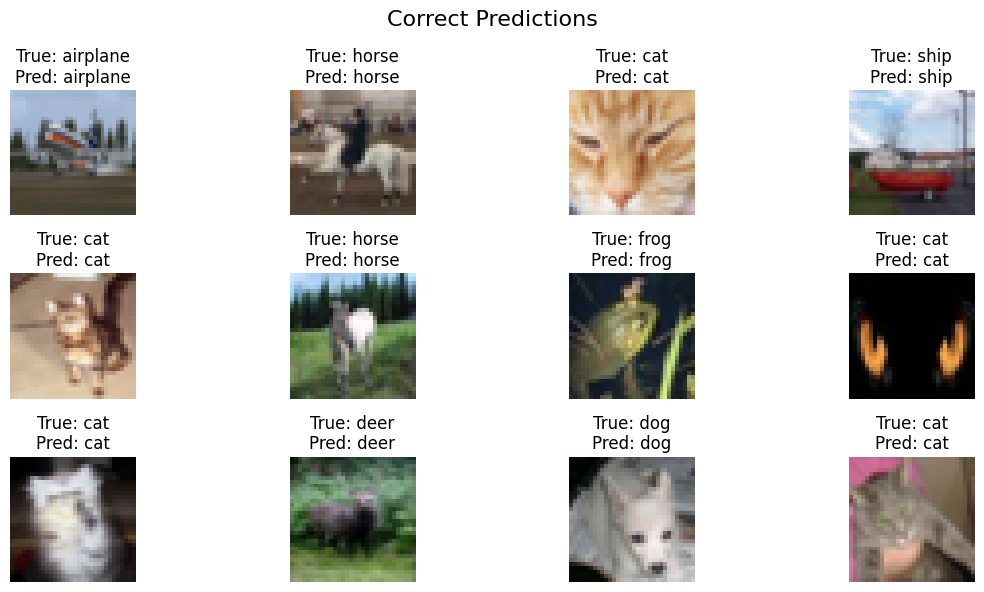

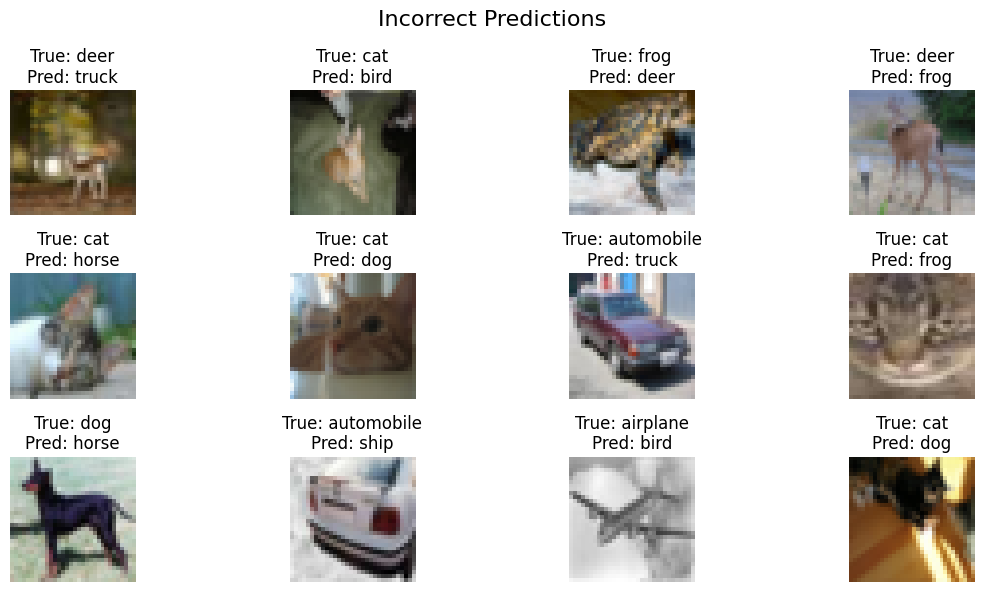

In [19]:
def show_prediction_examples(images, true_labels, pred_labels, class_names, correct=True, max_examples=12):
    if correct:
        indices = np.where(true_labels == pred_labels)[0]
        title = "Correct Predictions"
    else:
        indices = np.where(true_labels != pred_labels)[0]
        title = "Incorrect Predictions"

    selected = np.random.choice(indices, size=min(max_examples, len(indices)), replace=False)

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(selected):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[idx])
        true_name = class_names[int(true_labels[idx])]
        pred_name = class_names[int(pred_labels[idx])]
        plt.title(f"True: {true_name}\nPred: {pred_name}")
        plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

show_prediction_examples(test_images, true_labels, pred_labels, class_names, correct=True, max_examples=12)
show_prediction_examples(test_images, true_labels, pred_labels, class_names, correct=False, max_examples=12)

## 19. Interpretation of Results

The final results should be interpreted with respect to the project constraints. The model uses only 10,000 training images and is trained for a limited number of epochs. Therefore, the expected performance may be lower than a model trained on the full CIFAR-10 training set for many more epochs.

The most important points to discuss are the following:

| Observation area | How to interpret it |
|---|---|
| Training accuracy | Shows how well the model fits the reduced training data. |
| Validation accuracy | Indicates whether the model generalizes during training. |
| Test accuracy | Provides the final performance estimate on unseen data. |
| Confusion matrix | Reveals which classes are most often confused. |
| Incorrect examples | Helps explain model limitations visually. |

If fine-tuning improves validation and test accuracy, it suggests that adapting the ResNet50 features to CIFAR-10 was useful. If fine-tuning does not improve the results, the model may need a different learning rate, more data, data augmentation, or more careful layer selection.

## 20. Limitations and Possible Improvements

This project intentionally keeps the workflow manageable, but there are several limitations that affect performance.

| Limitation | Impact | Possible improvement |
|---|---|---|
| Only 10,000 training images | The model sees less visual variation. | Use the full 50,000 training images if runtime allows. |
| Limited number of epochs | The model may not fully converge. | Train for more epochs with early stopping. |
| Small image size | Fine details are difficult to learn. | Experiment with resizing images before ResNet50. |
| No data augmentation in the baseline | The model may overfit to the reduced training set. | Add random flips, rotations, zooms, and contrast changes. |
| Full fine-tuning can be slow | Training time increases significantly. | Fine-tune only the last ResNet blocks. |

A stronger version of this project could include data augmentation, learning-rate scheduling, early stopping, and a comparison between training only the head versus fine-tuning selected layers.

## 21. Optional Extension: Data Augmentation

The following code is optional. Data augmentation can improve generalization by exposing the model to modified versions of the same images. This is especially useful when the training set is small.

> **Notice.** If you use this extension, it should be integrated before training the model. For the required baseline workflow, the previous sections are already sufficient.

In [20]:
# Optional: data augmentation layer for future experimentation
# This cell is provided as an extension idea and is not required for the baseline run.

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

print("Data augmentation pipeline created. Integrate it before ResNet50 if you want to experiment further.")

Data augmentation pipeline created. Integrate it before ResNet50 if you want to experiment further.


## 22. Presentation Notes

For the live presentation, the focus should be on reasoning and insight rather than reading code line by line. The following points summarize the main story of the project.

| Presentation topic | Key message |
|---|---|
| Problem | The goal is to classify CIFAR-10 images into ten categories. |
| Dataset challenge | CIFAR-10 images are small RGB images, so visual details are limited. |
| Pipeline | The workflow is data loading, sampling, preprocessing, modeling, training, fine-tuning, and evaluation. |
| Transfer learning | ResNet50 provides useful pre-trained visual features from ImageNet. |
| Frozen training phase | The custom head learns to classify CIFAR-10 using fixed ResNet50 features. |
| Fine-tuning phase | The base model is unfrozen to adapt its features to CIFAR-10. |
| Evaluation | Test accuracy, confusion matrix, and example predictions show model performance and errors. |
| Improvements | More data, more epochs, augmentation, and better fine-tuning could improve performance. |

A strong presentation should clearly explain why each step was used, what changed between the two training phases, and what the results reveal about the model.

## 23. Final Conclusion

This notebook demonstrates a complete computer vision pipeline for CIFAR-10 image classification using transfer learning. The model uses ResNet50 as a pre-trained feature extractor, adds a custom classification head, trains the head first, and then fine-tunes the full model with a lower learning rate.

The project shows that model performance should not be judged only by final accuracy. A complete analysis also includes preprocessing decisions, training behavior, validation trends, class-level errors, visual inspection of predictions, and a realistic discussion of limitations.

The main learning outcome is understanding how to structure an image classification project from raw data to model evaluation and presentation.

## References

[1] A. Krizhevsky, "The CIFAR-10 Dataset", University of Toronto. Available: https://www.cs.toronto.edu/~kriz/cifar.html

[2] Keras, "CIFAR-10 small images classification dataset". Available: https://keras.io/api/datasets/cifar10/

[3] TensorFlow, "ResNet50 Documentation". Available: https://www.tensorflow.org/api_docs/python/tf/keras/applications/ResNet50

[4] Keras, "Keras Applications Documentation". Available: https://keras.io/api/applications/
